# WS6-200 Frequency Log Plotter

Visualise data saved by `monitor.py --log <file.csv>`.  
CSV format: `time_ns` (integer nanoseconds, monotonic) | `frequency_THz` (float).

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 2. Load CSV log

In [ ]:

import glob

# ── Find the most recent log file, or override manually ──────────────────────
_logs = sorted(glob.glob("logs/**/*.csv", recursive=True))
LOG_FILE = _logs[-1] if _logs else "run_001.csv"   # override: LOG_FILE = "path/to/file.csv"
SETPOINT_THz = 298.0044           # ~1006 nm — your laser setpoint; set to None to skip deviation plots
# ─────────────────────────────────────────────────────────────────────────────

print(f"Loading: {LOG_FILE}")
assert os.path.isfile(LOG_FILE), f"File not found: {LOG_FILE!r}"

df = pd.read_csv(LOG_FILE)
df["time_s"]        = (df["time_ns"] - df["time_ns"].iloc[0]) * 1e-9   # elapsed seconds
df["frequency_MHz"] = df["frequency_THz"] * 1e6                          # THz → MHz (full value)

if SETPOINT_THz is not None:
    df["deviation_MHz"] = (df["frequency_THz"] - SETPOINT_THz) * 1e6

# Derived sample rate
dt_s = np.diff(df["time_s"].values)
df_rate = pd.DataFrame({
    "time_s": df["time_s"].values[1:],
    "rate_Hz": 1.0 / dt_s,
})

print(f"Samples        : {len(df):,}")
print(f"Duration       : {df['time_s'].iloc[-1]:.2f} s")
print(f"Mean rate      : {1/dt_s.mean():.1f} Hz")
print(f"Mean frequency : {df['frequency_THz'].mean():.6f} THz")
if SETPOINT_THz is not None:
    print(f"Mean deviation : {df['deviation_MHz'].mean():+.3f} MHz")
    print(f"Std  deviation : {df['deviation_MHz'].std():.3f} MHz")


Loading: logs/2026-05-20/wlm_21-30-40.csv
Samples        : 606
Duration       : 5.86 s
Mean rate      : 103.3 Hz
Mean frequency : 384.230000 THz
Mean deviation : +0.203 MHz
Std  deviation : 1.029 MHz


## 3 & 4. Plots

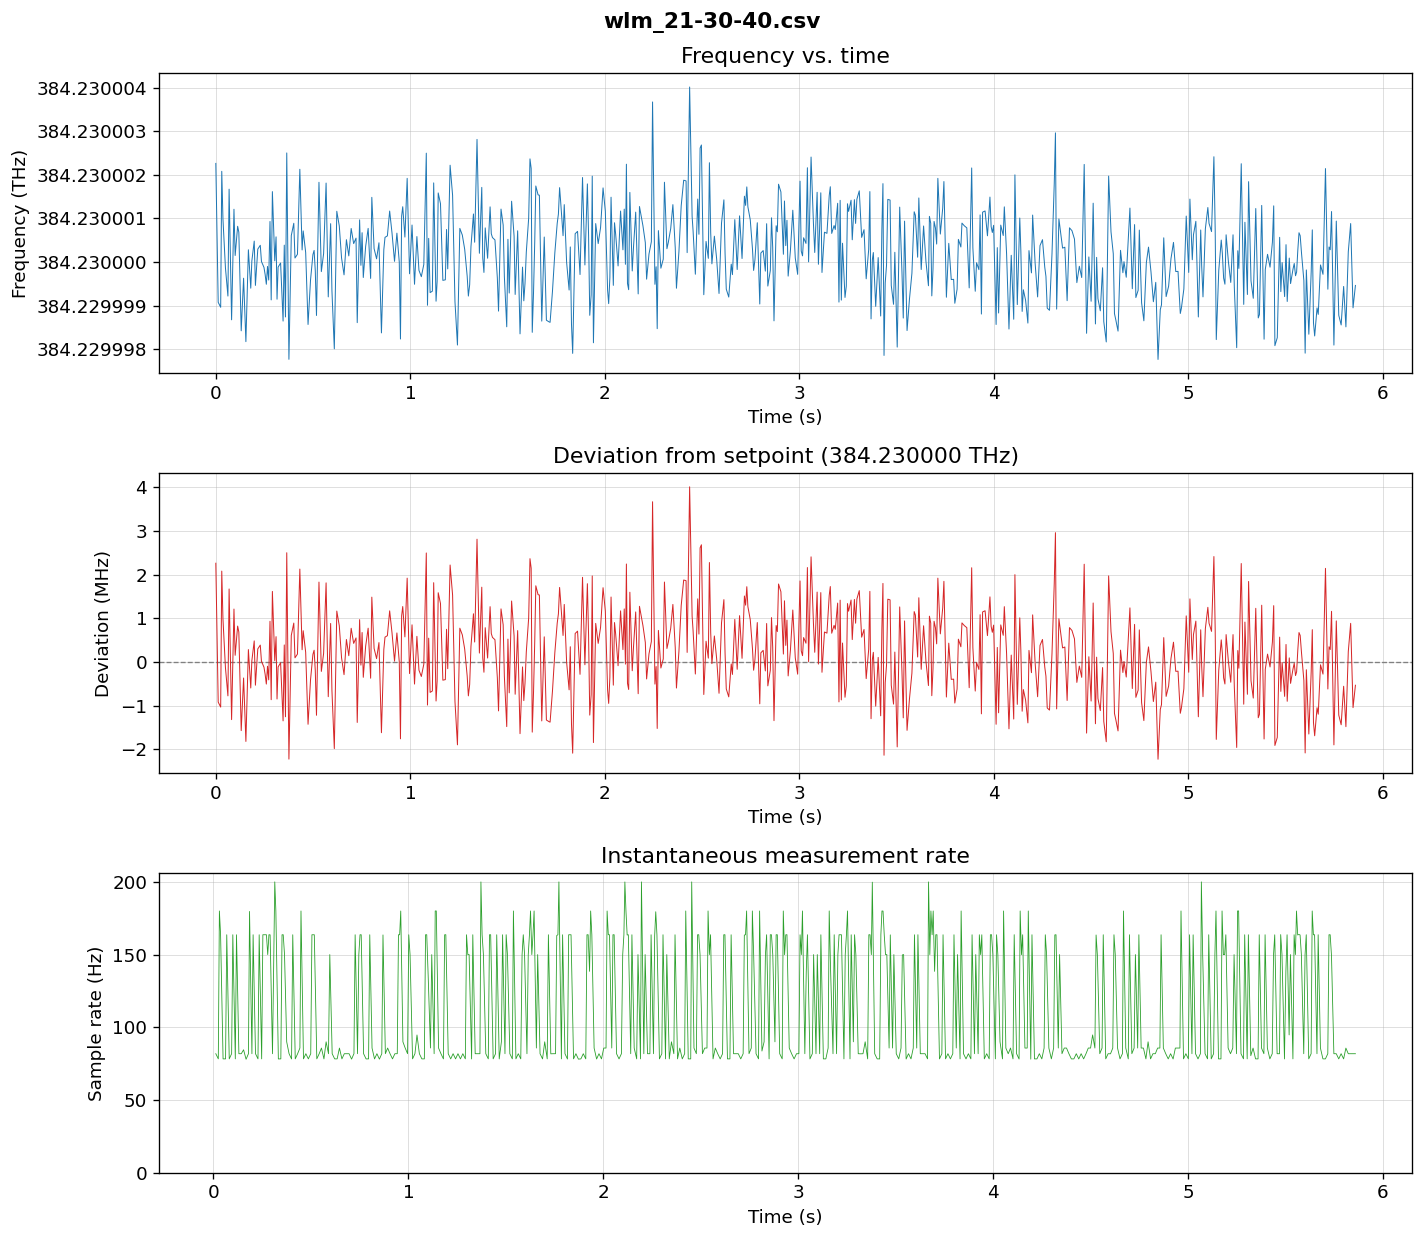

In [4]:
n_panels = 3 if SETPOINT_THz is not None else 2
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3.5 * n_panels), sharex=False)
fig.suptitle(os.path.basename(LOG_FILE), fontsize=13, fontweight="bold")

# ── Panel 1: raw frequency vs time ───────────────────────────────────────────
ax = axes[0]
ax.plot(df["time_s"], df["frequency_THz"], linewidth=0.6, color="#1f77b4", rasterized=True)
ax.set_ylabel("Frequency (THz)")
ax.set_xlabel("Time (s)")
ax.set_title("Frequency vs. time")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.6f"))
ax.grid(True, linewidth=0.4, alpha=0.6)

# ── Panel 2: deviation from setpoint (MHz) ───────────────────────────────────
if SETPOINT_THz is not None:
    ax2 = axes[1]
    ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax2.plot(df["time_s"], df["deviation_MHz"],
             linewidth=0.6, color="#d62728", rasterized=True)
    ax2.set_ylabel("Deviation (MHz)")
    ax2.set_xlabel("Time (s)")
    ax2.set_title(f"Deviation from setpoint ({SETPOINT_THz:.6f} THz)")
    ax2.grid(True, linewidth=0.4, alpha=0.6)
    rate_ax = axes[2]
else:
    rate_ax = axes[1]

# ── Panel 3 (or 2): instantaneous sample rate ────────────────────────────────
rate_ax.plot(df_rate["time_s"], df_rate["rate_Hz"],
             linewidth=0.5, color="#2ca02c", rasterized=True)
rate_ax.set_ylabel("Sample rate (Hz)")
rate_ax.set_xlabel("Time (s)")
rate_ax.set_title("Instantaneous measurement rate")
rate_ax.set_ylim(bottom=0)
rate_ax.grid(True, linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Save figure

In [ ]:
out_path = LOG_FILE.replace(".csv", "_plot.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")

## 6. Linewidth analysis

Three complementary estimates, all limited from below by the wavemeter's own measurement resolution:

| Estimate | What it measures |
|---|---|
| **Gaussian FWHM** (histogram / 2.355σ) | Total frequency spread over the whole run — dominated by slow drift |
| **Lorentzian FWHM** (PSD white-noise floor, π × S₀) | Instantaneous/intrinsic linewidth from fast white noise |
| **Allan deviation** | Frequency instability vs. averaging time — minimum = best stability timescale |

The dashed grey line on each plot marks the WS6-200 resolution floor at your laser wavelength (~0.001 pm). Results below that line are instrument-limited, not real.

In [ ]:
# ─── Signal to analyse: deviation from setpoint if available, else de-meaned freq ──
if "deviation_MHz" in df.columns:
    y_MHz  = df["deviation_MHz"].values
    y_label = "Freq. deviation from setpoint (MHz)"
else:
    y_MHz  = (df["frequency_THz"] - df["frequency_THz"].mean()).values * 1e6
    y_label = "Freq. (de-meaned, MHz)"

t_raw = df["time_s"].values

# ─── Resample to uniform time grid (required for FFT) ────────────────────────
dt  = np.median(np.diff(t_raw))   # robust to timestamp jitter
fs  = 1.0 / dt
t_u = np.arange(t_raw[0], t_raw[-1], dt)
y_u = np.interp(t_u, t_raw, y_MHz)
N   = len(y_u)

# ─── Welch PSD (MHz²/Hz) ─────────────────────────────────────────────────────
def welch_psd(y, fs, nperseg=None):
    N       = len(y)
    nperseg = nperseg or max(N // 4, 8)
    noverlap = nperseg // 2
    step    = nperseg - noverlap
    win     = np.hanning(nperseg)
    norm    = np.sum(win ** 2)
    segs, i = [], 0
    while i + nperseg <= N:
        seg = (y[i:i+nperseg] - y[i:i+nperseg].mean()) * win
        segs.append(np.abs(np.fft.rfft(seg)) ** 2)
        i  += step
    psd       = np.mean(segs, axis=0) / (norm * fs)
    psd[1:-1] *= 2                          # one-sided
    freqs     = np.fft.rfftfreq(nperseg, 1.0 / fs)
    return freqs[1:], psd[1:]              # drop DC bin

freqs, psd = welch_psd(y_u, fs)

# ─── Lorentzian FWHM from white-noise floor ──────────────────────────────────
# Estimate the floor as the median PSD in the top 20% of frequencies
# (where 1/f noise has rolled off and only shot/white noise remains).
S0               = np.median(psd[freqs > 0.8 * freqs[-1]])   # MHz²/Hz
lorentzian_MHz   = np.pi * S0                                  # FWHM = π × S₀

# ─── Gaussian FWHM from standard deviation over the run ──────────────────────
sigma_MHz       = y_MHz.std()
gaussian_MHz    = 2.3548 * sigma_MHz         # 2√(2 ln2) ≈ 2.355

# ─── Wavemeter resolution floor at the measured wavelength ───────────────────
freq_THz   = df["frequency_THz"].mean()
lambda_m   = 3e8 / (freq_THz * 1e12)         # wavelength in metres
dlambda_m  = 1e-15                            # 0.001 pm spec resolution
wlm_res_MHz = (3e8 / lambda_m**2 * dlambda_m) / 1e6

# ─── Overlapping Allan deviation ─────────────────────────────────────────────
def adev_overlapping(y, dt, taus):
    cs  = np.concatenate([[0.0], np.cumsum(y)])
    out = []
    for tau in taus:
        m = max(1, int(round(tau / dt)))
        if 2 * m >= len(y):
            break
        avg  = (cs[m:] - cs[:-m]) / m          # overlapping block averages
        avar = 0.5 * np.mean((avg[m:] - avg[:-m]) ** 2)
        out.append((tau, np.sqrt(avar)))
    return np.array(out) if out else np.empty((0, 2))

taus       = np.logspace(np.log10(2 * dt), np.log10((t_u[-1] - t_u[0]) / 3), 60)
ad         = adev_overlapping(y_u, dt, taus)

# ─── Summary ─────────────────────────────────────────────────────────────────
print(f"Wavemeter resolution at {lambda_m*1e9:.1f} nm : {wlm_res_MHz:.3f} MHz  (measurement floor)")
print()
print(f"Gaussian FWHM  (2.355σ, whole run) : {gaussian_MHz:.3f} MHz   — total frequency spread incl. drift")
print(f"Lorentzian FWHM (π × PSD floor)    : {lorentzian_MHz*1e3:.2f} kHz  — instantaneous/white-noise linewidth")
if len(ad):
    print(f"Allan dev. minimum                 : {ad[:,1].min():.3f} MHz  @ τ = {ad[ad[:,1].argmin(), 0]:.2f} s")
print()
if lorentzian_MHz < wlm_res_MHz:
    print(f"⚠  Lorentzian estimate ({lorentzian_MHz*1e3:.1f} kHz) is below the WLM resolution floor ({wlm_res_MHz:.1f} MHz) — instrument-limited.")
if gaussian_MHz < wlm_res_MHz:
    print(f"⚠  Gaussian estimate ({gaussian_MHz:.3f} MHz) is also below the WLM floor — need more signal or longer run.")